Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on ${}^{151}Eu$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy

In [2]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [3]:
#M tensor ground state
M = np.matrix(np.diag([0.443,0.5682,1.1193]))*10/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = -1*np.matrix(np.diag([-2.735,2.735,12.3797]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))

#rotated tensors
M_rot = np.array([144.9,34.9,98.1])*np.pi/180
Q_rot = np.array([-39.3,76.49,149.9])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str='ZYZ')
Q_G = spin.tensorRotation(Q,Q_rot,str='ZYZ')

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
ground.setgN(M_G)
#print(ground.H.shape)

[[  2.735    0.       0.    ]
 [  0.      -2.735    0.    ]
 [  0.       0.     -12.3797]]
Q [[-8.05309891  4.92442566 -0.95337412]
 [ 4.92442566 -4.93600935  3.76242426]
 [-0.95337412  3.76242426  0.60940826]]
M [[ 0.86681904 -0.17967655 -0.27127711]
 [-0.17967655  0.69749996  0.20667946]
 [-0.27127711  0.20667946  1.23066155]]


Mainloop for each B field value the following is performed:
- The B field is converted from spherical to cartesian coordinates
- We calculate our total hamiltonian consisting of the static hyperfine and/or quadrapole and the dynamic zeeman terms.
- We calculate the eigenvalues and eigenvectors of the hamiltonian, converting the eigenvalues to frequencies.
- We calculate the transition strength between each energy level based on the eigenvectors of the excited and ground states
- We calculate the spin transition probabilities based on the dynamic hamiltonian.

In [4]:
theta,phi = spin.eulerToSphere(M_rot,str='ZXZ')
theta = 1*np.pi/2
phi=1*np.pi/2

thetas=np.pi/2*np.linspace(-1,1,20)
phis=np.pi/2*np.linspace(-1,1,20)
Bs=np.logspace(-3,1,100)
#Bs = np.linspace(0,10,1000)

#Bs=[0,0.1]

#thetas = [theta]
#phis = [phi]


OsDim = ground.dim**2

#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = ground.initSweep(thetas,phis,Bs)

#OS = ground.initSweep(thetas,phis,Bs,ground.dim**2)
OS_SG = ground.initSweep(thetas,phis,Bs,OsDim)
#OS_SG = np.zeros((len(thetas),len(phis),len(Bs),ground.dim,3),dtype = np.csingle)#

CS_G = ground.initSweep(thetas,phis,Bs,ground.dim)
#CS_G = np.zeros((len(thetas),len(phis),len(Bs),3,3))

Bac = np.matrix([1,1,1]).T

BC = np.eye(3)
#print('Q',Q_G)
Is = spin.spinOperator(Ispin,matricies=True)

As = spin.genAMatrix(spin.muN*M_G,Is)

off= np.matrix([-0.535,-0.634,0.558]).T
off = np.asmatrix(Rotation.from_euler('ZYZ',Q_rot).as_matrix())@off
print("Off: ",off,"Off mag",np.linalg.norm(off))
#off= np.matrix([0,0,0]).T

#print(As[0])
#print(As)

#our loop
for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(Bs)):
            #convert spherical Magnetic field to cartesian coords.
            unit =spin.sphereCart(1,thetas[i],phis[j])
            #unit = unit/np.linalg.norm(unit)
            #unit=off
            B = Bs[k]*unit
            
            #Calculate our hamiltonian at this B Field
            HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
            #HG = H+ground.nuclearZeeman(B)#/spin.muN
            
            #get the eigen frequencies and vectors at this B field
            FG,VG = ground.getEigFreq(HG)
            FreqG[i,j,k,:]=FG*1E3
            
            #print(i,j,k)
            #print(np.sign(np.real(VG)))
            #print(np.sign(np.imag(VG)))


            OS = np.zeros((ground.dim,3),dtype = np.csingle)
            for l in range(3):
                OS[:,l] = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
            #print(OS)
            M = OS@unit
            #print(M)
            M = (np.squeeze(M[:,0]))
            #print(M.shape,np.squeeze(M[:,0]))
            OS_SG[i,j,k,:]=spin.eachElemFunc(M,M,ax=1)
            #OS_SG[i,j,k,:]=M
            
            S = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False)#*spin.muN
            E = np.linalg.eigvalsh(S)
            CS_G[i,j,k,:]= (E[np.abs(E).argmax()])
            #=
            #print(S)
            
           
pass

Off:  [[ 0.73848249]
 [-0.24235355]
 [-0.62885083]] Off mag 0.9997724741159859


Plotting of energy levels for both the ground and excited state.

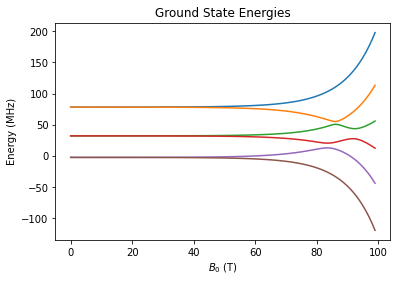

In [5]:

#Plot our energy levels
F_S = np.squeeze(np.real(FreqG[0,0,:,:]))
plt.plot(F_S)
#plt.ylim([-30,90])
#plt.grid()
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (T)")
plt.ylabel("Energy (MHz)")
plt.savefig('../Eu')
plt.show()
plt.close()

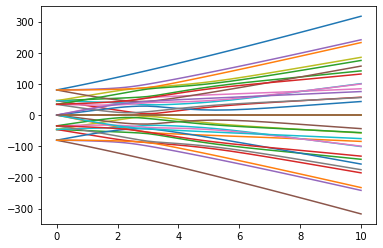

In [6]:
Ts = spin.eachElemFunc(F_S,F_S,ax=1)
plt.plot(Bs,Ts[:,:])
plt.show()
plt.close()

# ZEFOZ notes:
Critical points occur when:
$$\frac{\partial f_{nm}}{\partial B_{i}} = \left<\psi_{n}\right|A_{i}\left|\psi_{m}\right>=0$$

Our sensitivity is the extension:
$$\vec{S}_{1} = \frac{\partial f_{nm}}{\partial B_{x}}\vec{i}+\frac{\partial f_{nm}}{\partial B_{y}}\vec{j}+\frac{\partial f_{nm}}{\partial B_{z}}\vec{k}$$

Maximum curvature given by the largest eigenvalue of $S_{2}$
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

Where
$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

This gives our $T_{2}$ time at a ZEFOZ point:
$$\frac{1}{\pi T_{2}} = \vec{S}_{1}\cdot\Delta\vec{B}+\Delta\vec{B}\cdot\vec{S}_{2}\cdot\Delta\vec{B}$$

(100, 36)
(100, 6)
Cartesian Coords:  [[-1.86582824e-16 -1.00000000e+00 -1.58883612e-16]]


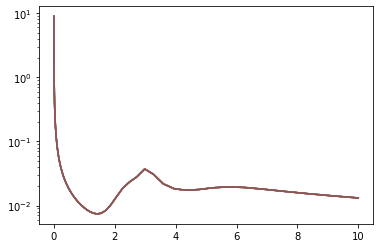

(100, 36) (0.019443007-4.2296717e-19j)
Norm 1.0


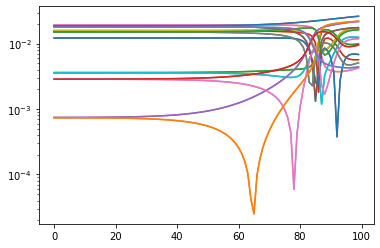

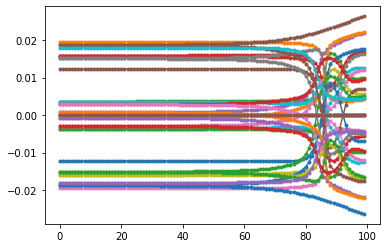

(100, 36)
(100, 36)


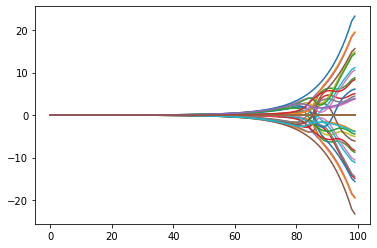

In [7]:
#Plot our energy levels
CS_S= np.abs(np.squeeze(CS_G[0,0,:,:]))
OS_Sq = (np.squeeze(OS_SG[0,0,:,:]))
OS_S = np.abs(OS_Sq)

print(OS_S.shape)
print(CS_S.shape)


cart =np.multiply(spin.sphereCart(1,thetas[0],phis[0]),off)
cart/=np.linalg.norm(cart)
print("Cartesian Coords: ",cart.T)            
#print(OS_S[1,1,:],np.matrix(OS_S[1,1,:])@cart)
thres = 1E-10

plt.semilogy(Bs,CS_S)
#plt.ylim([None,1E-2])
plt.show()
plt.close()
#plt.semilogy(Bs,np.linalg.norm(OS_S,axis=2),'*-')
#plt.semilogy(Bs,OS_S.reshape((len(Bs),18)),'*-')

gradCalc  = OS_Sq#spin.eachElemFunc(OS_Sq,OS_Sq,ax=1)

plt.semilogy(np.abs(gradCalc)[:,:],'-')
print(gradCalc.shape,gradCalc[1,1])
print("Norm", np.linalg.norm(cart))
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.show()
plt.close()


plt.plot(np.real(gradCalc[:,:]),'.-')
#plt.plot(Bs,np.ones_like(Bs)*0,'r--')
#plt.ylim([-1E-5,1E-5])
plt.show()
plt.close()

print(Ts.shape)
grad = np.gradient(Ts,axis=0)
print(grad.shape)
plt.plot((grad))
plt.show()
plt.close()



(20, 20, 100, 6)


c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


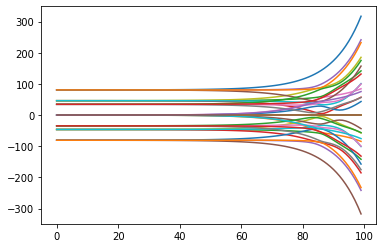

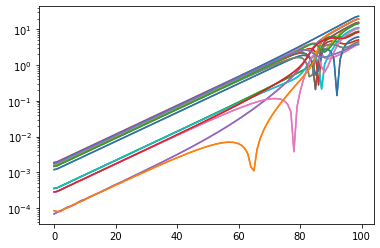

In [8]:
Fs = FreqG
print(Fs.shape)

Ts = spin.eachElemFunc(Fs,Fs,ax=3)
grad = np.gradient(Ts,axis=2)


plt.plot(Ts[0,0,:,:])
plt.show()
plt.close()

plt.semilogy(np.abs(grad[0,0,:,:]))
plt.show()
plt.close()


GS (20, 20, 100, 36)
OS (20, 20, 100, 36)
(20, 20, 100, 6)
(7192, 4)
[64 64 78 ... 86 92 92]


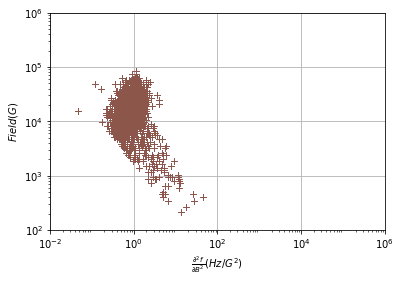

In [9]:


print('GS',grad.shape)
print('OS',OS_SG.shape)

zero_crossings =lambda a: np.argwhere(np.diff(np.sign(a),axis=2))
id = (zero_crossings(OS_SG))
CS_G = np.abs(CS_G)

print(CS_G.shape)
print(id.shape)

#print(id)
print(id[:,2])
#print(np.unique(Bs[id[:,2]]))

plt.loglog(2*np.pi*CS_G[id[:,0],id[:,1],id[:,2],:]*1E1,Bs[id[:,2]]*1E4,'+')
plt.ylabel(r'$Field(G)$')
plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
plt.xlim([1E-2,1E6])
plt.ylim([1E2,1E6])
plt.xticks([1E-2,1E0,1E2,1E4,1E6])
plt.grid()
plt.show()
plt.close()


